# [2.0] DESI x Gaia Crossmatch

In this notebook, we will:
- **crossmatch** the DESI Main Survey (dark program) DR1 with Gaia DR3
- **save** the resulting catalog to the NERSC Community File System (CFS)
- discuss **performance and resource use** of the crossmatch

## Set up

In [42]:
import os
import time
from pathlib import Path

import lsdb
import matplotlib.pyplot as plt
import pandas as pd
from dask.distributed import Client, performance_report
from hats.io.validation import is_valid_catalog

In [2]:
# Check on our output directory

users_dir = Path("/global/cfs/cdirs/cosmo/users/")
target_user_dir = users_dir / "olynn"

! tree -L 1 $target_user_dir

/global/cfs/cdirs/cosmo/users/olynn
├── desi-dr1-coadd-test
└── desi-dr1-main-dark

2 directories, 0 files


In [ ]:
# Make a dask client

client = Client(
    n_workers=32,
    threads_per_worker=2,
    memory_limit="14GB",   # 32 × 14 = 448 GB, well within 487 GB
)

In [4]:
# Set up dashboard port forwarding instructions for the user. 
# Note that the compute node hostname is needed to set up the ssh tunnel correctly.

import socket

username = os.getenv("USER")
current_compute_node = socket.gethostname()

print(f"1. In a local shell, run: ssh -L 8787:{current_compute_node}:8787 {username}@perlmutter.nersc.gov")
print("2. Enter password + OTP")
print(f"3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status")

1. In a local shell, run: ssh -L 8787:nid004212:8787 olynn@perlmutter.nersc.gov
2. Enter password + OTP
3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status


## Load catalogs

In [5]:
desi_cat = lsdb.open_catalog("/global/cfs/cdirs/cosmo/users/olynn/desi-dr1-main-dark")
desi_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z
npartitions=5769,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12286",...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12287",...,...,...,...,...,...,...,...


In [6]:
gaia_cat = lsdb.open_catalog(
    "s3://stpubdata/gaia/gaia_dr3/public/hats",
    columns=["source_id", "ra", "dec"])
gaia_cat

,source_id,ra,dec
npartitions=2016,,,
"Order: 2, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow]
"Order: 2, Pixel: 1",...,...,...
...,...,...,...
"Order: 3, Pixel: 766",...,...,...
"Order: 3, Pixel: 767",...,...,...


## Do crossmatch

In [9]:
desi_x_gaia = desi_cat.crossmatch(gaia_cat, suffix_method="overlapping_columns", suffixes=("_desi", "_gaia"))

In [ ]:
start = time.perf_counter()

with performance_report(filename="crossmatch_report.html"):
    desi_x_gaia.write_catalog(
        base_catalog_path=target_user_dir,
        catalog_name="desi_x_gaia",
    )

elapsed = time.perf_counter() - start

In [51]:
print(f"Crossmatch took {int(elapsed/60):d}m {elapsed%60:.1f}s")

Crossmatch took 10m 42.1s


## Verify crossmatched catalog

In [15]:
# Check that the catalog was written correctly

output_catalog = target_user_dir / "desi_x_gaia"

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

Validating catalog at path /global/cfs/cdirs/cosmo/users/olynn/desi_x_gaia ... 
Found 5764 partitions.
Approximate coverage is 33.38 % of the sky.


True

In [16]:
# Calculate size of the catalog on disk

! du -sh $output_catalog

/global/common/software/nersc/pe/conda-envs/26.1.0/python-3.12/nersc-python/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=876099) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


71G	/global/cfs/cdirs/cosmo/users/olynn/desi_x_gaia


In [17]:
# Open catalog

desi_x_gaia_cat = lsdb.open_catalog(output_catalog)
desi_x_gaia_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z,source_id,ra,dec,_dist_arcsec
npartitions=5764,,,,,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12286",...,...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12287",...,...,...,...,...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi_x_gaia'}>)

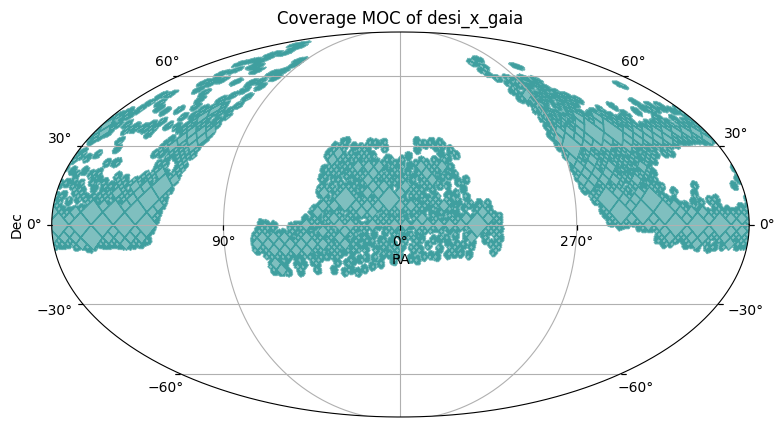

In [18]:
# Plot coverage

desi_x_gaia_cat.plot_coverage()

In [19]:
# See the first few rows

df = desi_x_gaia_cat.head(5)
df

TARGETID  TARGET_RA  TARGET_DEC         Z      ZERR  \
_healpix_29                                                                   
1748843556674  39627791523645551  45.075505    0.152316  2.225343  0.000244   
2652981825998  39627791519454588  44.925441    0.149561   0.00001  0.000004   
2976627719789  39627791519453248  44.884761    0.164806  0.807195  0.000015   
3287693392179  39627791519454413  44.919962    0.215757  0.808562   0.00007   
3679366411269  39627791523644892  45.050386    0.219434 -0.000279  0.000009   

                                                       spectra_b  \
_healpix_29                                                        
1748843556674  [{wavelength: 3600.0, flux: 2.246889, ivar: 0....   
2652981825998  [{wavelength: 3600.0, flux: -0.806199, ivar: 0...   
2976627719789  [{wavelength: 3600.0, flux: 6.968853, ivar: 0....   
3287693392179  [{wavelength: 3600.0, flux: 2.379487, ivar: 0....   
3679366411269  [{wavelength: 3600.0, flux: 5.181625, ivar: 0....   

                                                       spectra_r  \
_healpix_29                                                        
1748843556674  [{wavelength: 5760.0, flux: 0.119673, ivar: 6....   
2652981825998  [{wavelength: 5760.0, flux: 5.079622, ivar: 7....   
2976627719789  [{wavelength: 5760.0, flux: 1.523983, ivar: 3....   
3287693392179  [{wavelength: 5760.0, flux: 2.873809, ivar: 0....   
3679366411269  [{wavelength: 5760.0, flux: 8.459776, ivar: 1....   

                                                       spectra_z  \
_healpix_29                                                        
1748843556674  [{wavelength: 7520.0, flux: 1.12132, ivar: 22....   
2652981825998  [{wavelength: 7520.0, flux: 3.271897, ivar: 17...   
2976627719789  [{wavelength: 7520.0, flux: 0.590848, ivar: 16...   
3287693392179  [{wavelength: 7520.0, flux: 0.994231, ivar: 6....   
3679366411269  [{wavelength: 7520.0, flux: 5.367475, ivar: 4....   

                   source_id         ra       dec  _dist_arcsec  
_healpix_29                                                      
1748843556674  3470333738112  45.075505  0.152316      0.000927  
2652981825998  5295694864384  44.925444  0.149559      0.012942  
2976627719789  5944234902272  44.884761  0.164806      0.000834  
3287693392179  6567005330944  44.919961  0.215756      0.005419  
3679366411269  7352984181120  45.050386  0.219434      0.002946

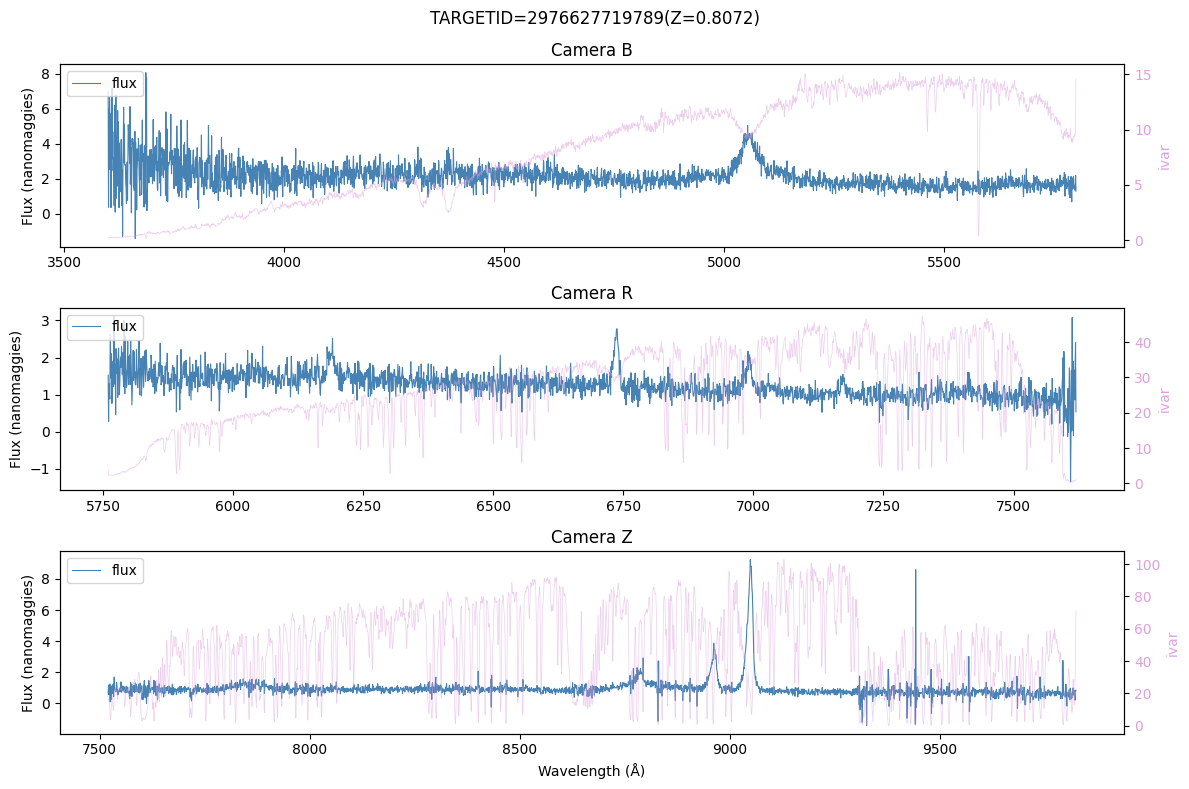

In [27]:
# Plot spectra of a row

target_idx = 2

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
colors = ["steelblue", "plum"]

# Iterate over the three cameras and plot the spectra for the target at target_idx.
for ax, cam in zip(axes, ["b", "r", "z"]):
    # Get the spectrum.
    spec = df[f"spectra_{cam}"].iloc[target_idx]

    # Plot flux on the primary y-axis.
    ax.plot(spec["wavelength"], spec["flux"], lw=0.8, color=colors[0], label="flux")
    
    # Plot ivar on the secondary y-axis.
    ax_twin = ax.twinx()
    ax_twin.plot(spec["wavelength"], spec["ivar"], lw=0.5, color=colors[1], alpha=0.5, label="ivar")
    ax_twin.set_ylabel("ivar", color=colors[1])
    ax_twin.tick_params(axis="y", labelcolor=colors[1])
    
    # Set labels and title for the primary y-axis.
    ax.set_ylabel("Flux (nanomaggies)") # https://desidatamodel.readthedocs.io/en/latest/DESI_SPECTRO_DATA/NIGHT/EXPID/fibermap-EXPID.html#required-data-table-columns:~:text=nanomaggies
    ax.set_title(f"Camera {cam.upper()}")
    ax.legend(loc="upper left")

# Set x-axis label and overall figure title.
axes[-1].set_xlabel("Wavelength (Å)")
fig.suptitle(f"TARGETID={df.index[target_idx]}(Z={df['Z'].iloc[target_idx]:.4f})")
plt.tight_layout()
plt.show()

## Performance Analysis

### 1. Setup

The crossmatch was run on a Perlmutter CPU node at NERSC using a local Dask distributed 
client. The full DESI Main Survey (Dark Program), stored on the NERSC Community File System 
(CFS), was crossmatched against the full Gaia DR3 catalog, accessed remotely from the STScI 
public S3 bucket (`s3://stpubdata/gaia/gaia_dr3/public/hats`).

The Dask client was configured as follows:


| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | 2 |
| Total threads | 64 |
| Memory per worker | 14 GB |
| Total memory | 448 GB |

### 2. Wall Time

The full crossmatch — from the `desi.crossmatch(gaia).compute()` call to completion —
took **642.1 seconds** (~10.7 minutes) as measured by `time.perf_counter()`.

This reflects total wall time on a single Perlmutter CPU node, including task graph 
construction, data reads from both the local CFS (DESI) and remote S3 (Gaia), and 
the crossmatch computation itself. Sub-step timing was not recorded separately; the 
Dask performance report in section 3 provides a finer-grained breakdown of where time 
was spent.

### 3. Dask Performance Report

The Dask performance report recorded a wall time of **10m 40s** across **34,896 tasks**,
consistent with the `perf_counter` measurement. Key metrics from the report summary are
as follows:

| Metric | Value |
|---|---|
| Total tasks | 34,896 |
| Wall time | 10m 40s |
| Compute time (all workers) | 4hr 50m |
| Transfer time | 15m 13s |
| Disk read time | 1.13s |
| Disk write time | 0.92s |
| Total bandwidth | 606.20 MiB |

The aggregate compute time of **4hr 50m** distributed across 32 workers yields an average
of ~9 minutes per worker, closely matching the observed wall time and indicating good
worker utilization with little idle time. 

The most notable cost was **transfer time at 15m 13s**, which reflects the remote S3 read
of the Gaia catalog. Despite 606.20 MiB of total data movement, this transfer overhead
was modest relative to compute.

Disk read and write times were effectively zero (1.13s and 0.92s respectively), indicating
that no meaningful spilling to disk occurred and that the 448 GB total memory allocation
was comfortably sufficient for this crossmatch.

### 4. Recommendations

For exploratory work or science cases that do not require full-sky coverage, we recommend
applying a `cone_search` to reduce the working set before crossmatching. This can make the
job tractable on fewer resources and is a good way to validate analysis code before
committing to a full batch job.

For full-sky crossmatches, an HPC allocation is strongly recommended. The configuration
used here (32 workers, 2 threads per worker, 14 GB memory per worker) performed well on
a Perlmutter CPU node with good worker utilization and modest transfer overhead. This can
serve as a reasonable starting point for similar jobs.

When accessing remote catalogs over S3, transfer time is a real but manageable cost —
the aggregate transfer time across all workers was 15m 13s, though in practice this
overlapped with compute and did not add meaningfully to the overall wall time.